In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 645.7 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/9.8 MB 645.7 kB/s eta 0:00:15
   --- ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\HASNAIN\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
# 1. Import libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [4]:
# 2. df = pd.read_csv("bmw_cars_market_dataset_synthetic.csv")

print("\nFirst 5 rows")
print(df.head())

print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())


First 5 rows
   car_id     model  year  engine_size  horsepower fuel_type transmission  \
0       1        X5  2016          4.0         272    diesel    automatic   
1       2  1 Series  2022          2.6         218    petrol    automatic   
2       3        X1  2012          2.2         240    petrol    automatic   
3       4        X5  2022          3.8         316    diesel          NaN   
4       5  7 Series  2023          3.1         294    petrol    automatic   

  drivetrain  mileage_km  fuel_consumption_l_per_100km  price_usd  \
0        AWD       74655                           8.9      66756   
1        FWD       23469                           8.4      26867   
2        FWD      123273                           7.8      31313   
3        AWD       33064                           9.4      81594   
4        RWD       23926                           NaN     104105   

   co2_emissions_g_km  doors  seats  body_type  color  owner_count  \
0               196.0      5      5   


Missing Values: 
car_id                            0
model                             0
year                              0
engine_size                     243
horsepower                        0
fuel_type                         0
transmission                    215
drivetrain                        0
mileage_km                        0
fuel_consumption_l_per_100km    246
price_usd                         0
co2_emissions_g_km              225
doors                             0
seats                             0
body_type                         0
color                           239
owner_count                     255
accident_history                254
service_history                 231
country_sold                      0
dtype: int64


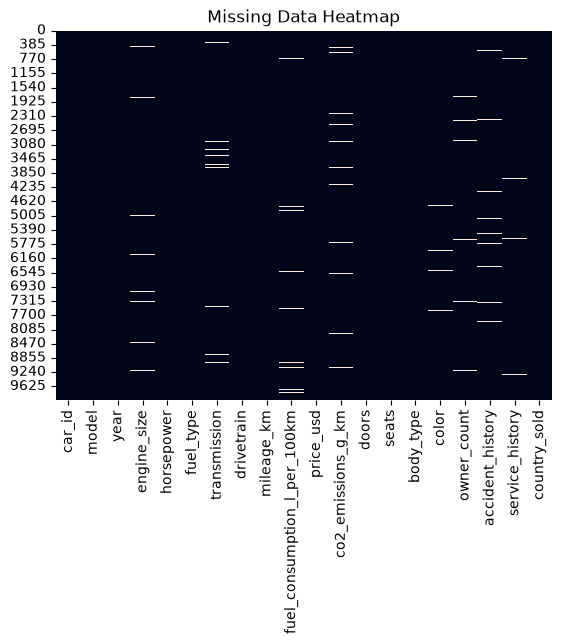

In [5]:
# 3. Check Missing values

print("\nMissing Values: ") 
print(df.isnull().sum())
# Visualizing missing values 
sns.heatmap(df.isnull(), cbar=False) 
plt.title("Missing Data Heatmap") 
plt.show()

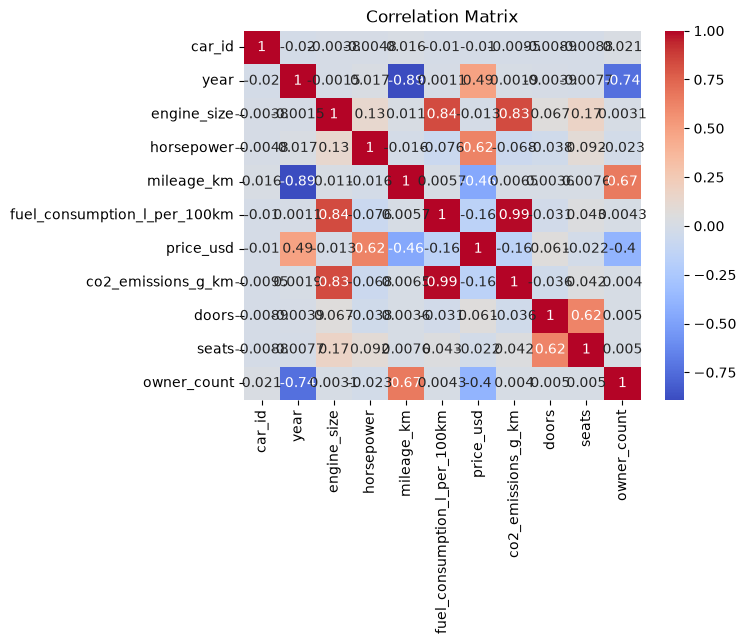

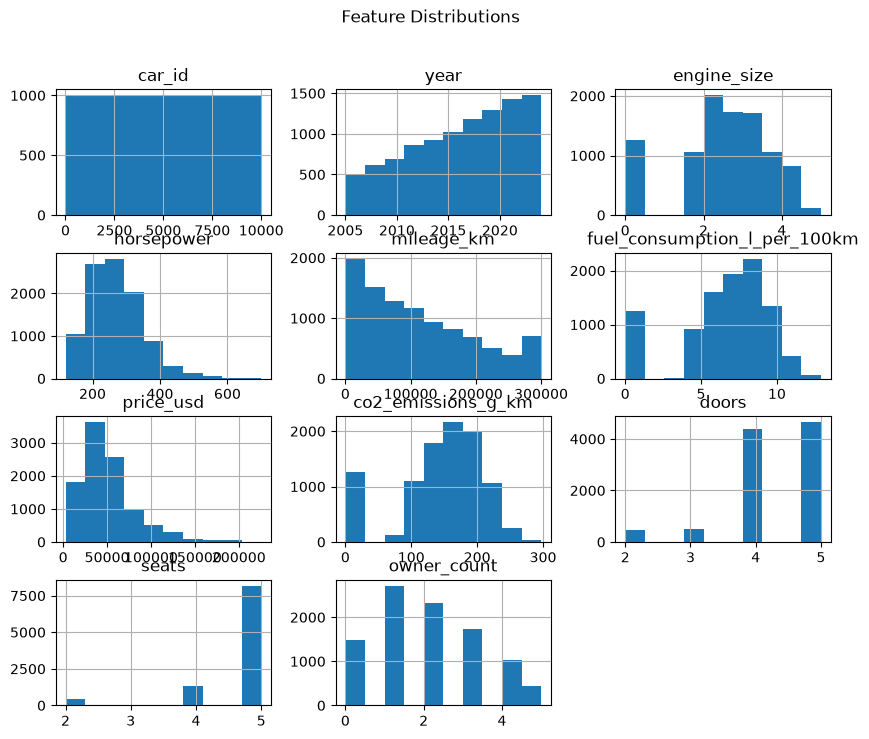

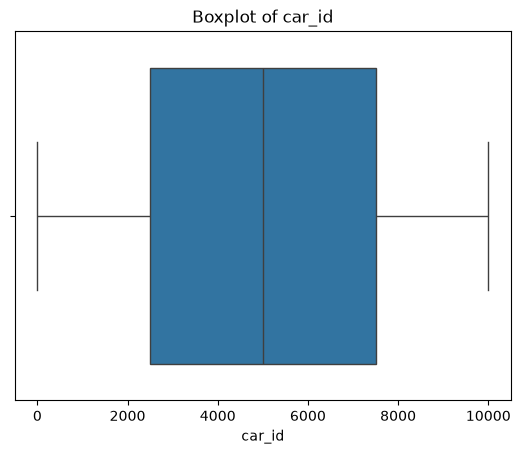

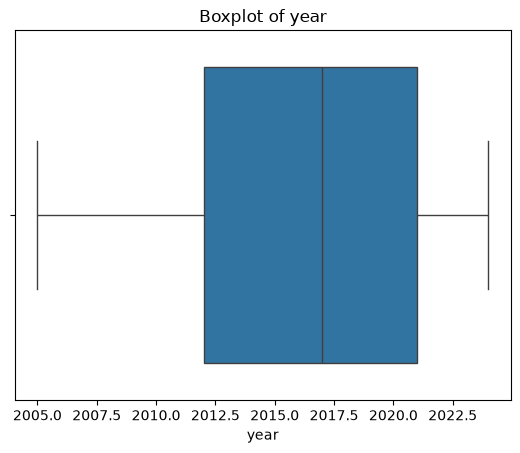

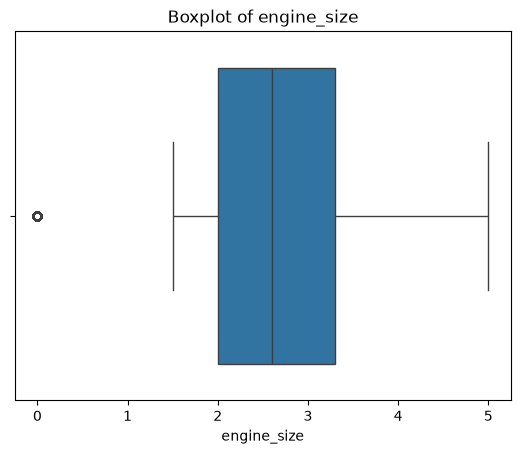

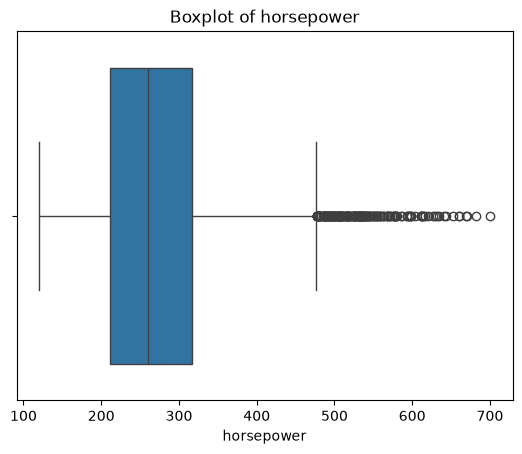

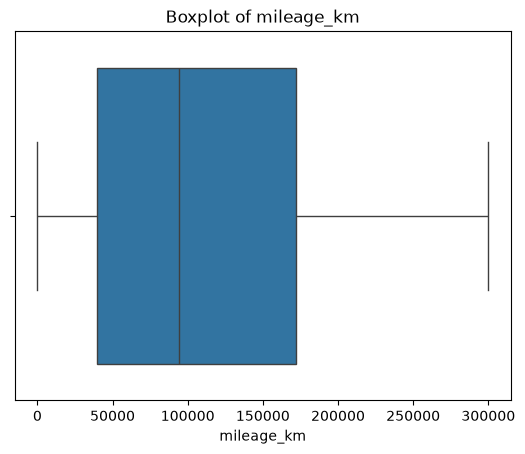

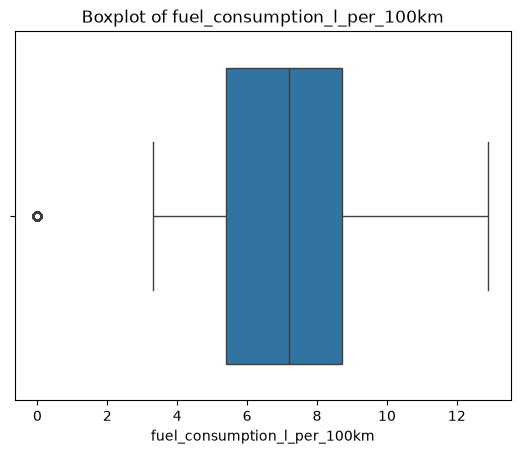

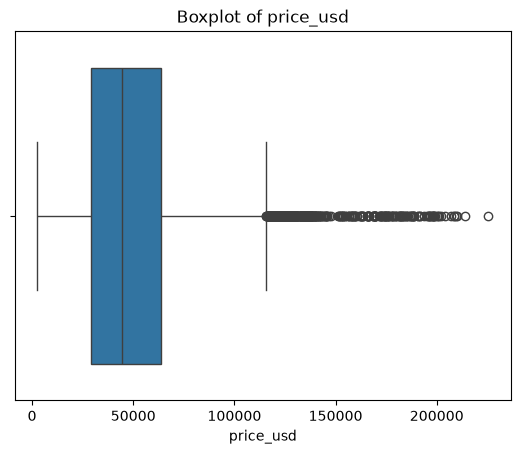

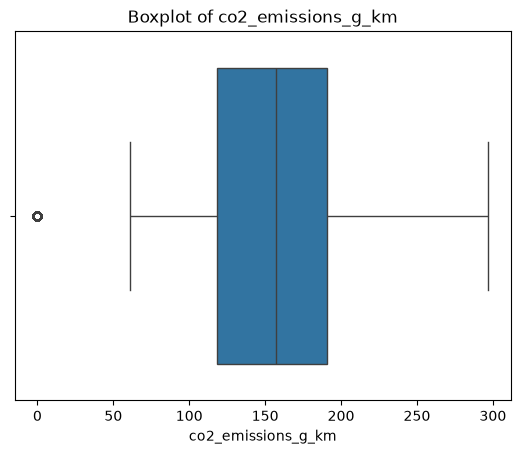

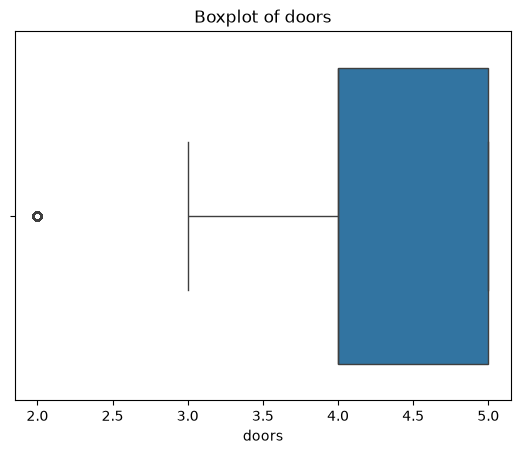

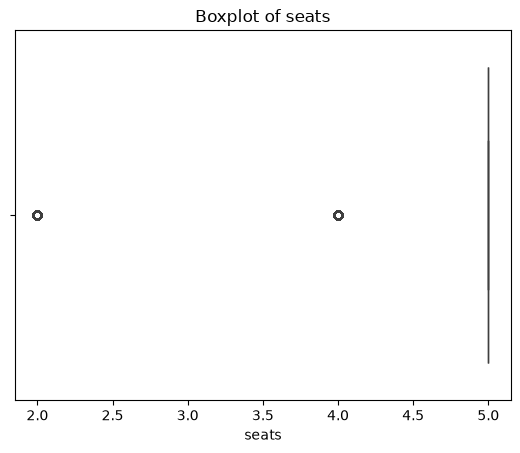

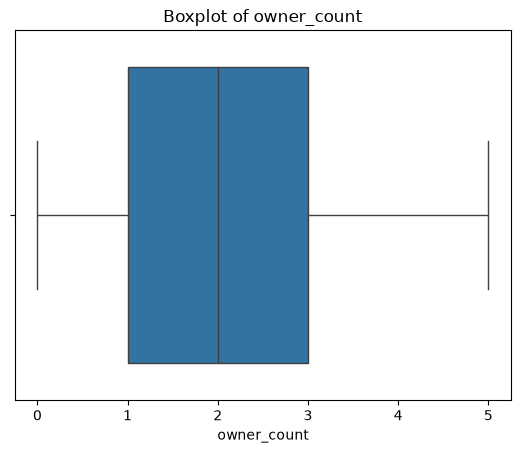

In [7]:
# 4. Basic EDA
# Correlation heatmap plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# Distribution of numeric features 
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions") 
plt.show()


# Boxplots for outliers
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [11]:
# 5. Data Cleaning


# Remove duplicate rows
df = df.drop_duplicates()


# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

#Label encoding categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# Handle missing values
imputer = SimpleImputer(strategy="mean")
df [numeric_cols] = imputer.fit_transform(df[numeric_cols])
print("\nDataset Info")
print(df.info())


Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  float64
 1   model                         10000 non-null  int64  
 2   year                          10000 non-null  float64
 3   engine_size                   10000 non-null  float64
 4   horsepower                    10000 non-null  float64
 5   fuel_type                     10000 non-null  int64  
 6   transmission                  10000 non-null  int64  
 7   drivetrain                    10000 non-null  int64  
 8   mileage_km                    10000 non-null  float64
 9   fuel_consumption_l_per_100km  10000 non-null  float64
 10  price_usd                     10000 non-null  float64
 11  co2_emissions_g_km            10000 non-null  float64
 12  doors                         10000 non-null  float64
 13 